In [104]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [105]:
yt_df = pd.read_csv('USvideos.csv', parse_dates=['publish_time'])

In [106]:
yt_df['trending_date'] = pd.to_datetime(yt_df['trending_date'], format="%y.%d.%m")

In [107]:
yt_df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:13:01+00:00,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00+00:00,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12 19:05:24+00:00,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13 11:00:04+00:00,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12 18:01:41+00:00,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


In [108]:
yt_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   video_id                40949 non-null  object             
 1   trending_date           40949 non-null  datetime64[ns]     
 2   title                   40949 non-null  object             
 3   channel_title           40949 non-null  object             
 4   category_id             40949 non-null  int64              
 5   publish_time            40949 non-null  datetime64[ns, UTC]
 6   tags                    40949 non-null  object             
 7   views                   40949 non-null  int64              
 8   likes                   40949 non-null  int64              
 9   dislikes                40949 non-null  int64              
 10  comment_count           40949 non-null  int64              
 11  thumbnail_link          40949 non-null  o

In [109]:
yt_df.describe()

,trending_date,category_id,views,likes,dislikes,comment_count
count,40949,40949.000000,4.094900e+04,4.094900e+04,4.094900e+04,4.094900e+04
mean,2018-02-27 06:22:42.494810624,19.972429,2.360785e+06,7.426670e+04,3.711401e+03,8.446804e+03
min,2017-11-14 00:00:00,1.000000,5.490000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,2018-01-04 00:00:00,17.000000,2.423290e+05,5.424000e+03,2.020000e+02,6.140000e+02
50%,2018-02-26 00:00:00,24.000000,6.818610e+05,1.809100e+04,6.310000e+02,1.856000e+03
75%,2018-04-24 00:00:00,25.000000,1.823157e+06,5.541700e+04,1.938000e+03,5.755000e+03
max,2018-06-14 00:00:00,43.000000,2.252119e+08,5.613827e+06,1.674420e+06,1.361580e+06
std,NaN,7.568327,7.394114e+06,2.288853e+05,2.902971e+04,3.743049e+04


In [110]:
yt_df.sample(5)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
21425,fKuxh0E9mSI,2018-03-03,CHVRCHES - My Enemy ft. Matt Berninger,ChvrchesVEVO,10,2018-02-28 17:05:00+00:00,"CHVRCHES|""My""|""Enemy""|""Virgin""|""Alternative""",232167,7552,266,622,https://i.ytimg.com/vi/fKuxh0E9mSI/default.jpg,False,False,False,‘Love Is Dead’ is available to pre-order now: ...
9815,IoqDYnn7VKA,2018-01-02,Original Bellas rehearsal video from Pitch Per...,Rebel Wilson,23,2017-12-29 17:32:51+00:00,"Anna|""Kendrick""|""Camp""|""Brittany""|""Snow""|""Rebe...",424620,7774,542,551,https://i.ytimg.com/vi/IoqDYnn7VKA/default.jpg,False,False,False,"Back in 2011, we were just getting to know eac..."
40644,E5yFcdPAGv0,2018-06-13,Gorillaz - Humility (Official Video),Gorillaz,10,2018-05-31 15:57:04+00:00,"humility|""Gorillaz Humanz""|""the now now""|""geor...",24280015,903304,29801,77951,https://i.ytimg.com/vi/E5yFcdPAGv0/default.jpg,False,False,False,‘Humility' feat. George Benson is taken from t...
20898,Zfpf5dnYA4Q,2018-02-28,This Roller Makes Plain Concrete Look Like Bri...,Tech Insider,28,2018-02-23 10:58:17+00:00,"Tech Insider|""TI""|""Tech""|""Science""|""Innovation...",146873,2090,114,300,https://i.ytimg.com/vi/Zfpf5dnYA4Q/default.jpg,False,False,False,"This is Rock 'N' Roller, it's a concrete rolle..."
12661,YkfsQKs659k,2018-01-18,How To Make A PEPPERMINT CHOCOLATE MEGA CAKE |...,How To Cake It,26,2018-01-16 16:00:12+00:00,"Google|""YouTube""|""Yolanda Gampp""|""Yolanda Gamp...",540142,23226,307,2591,https://i.ytimg.com/vi/YkfsQKs659k/default.jpg,False,False,False,My Cakebook Is Available WORLDWIDE! http://bit...


Ideas:
Most popular category ID's,
Best time of the year/month to post (Time of year, Views/Likes)

In [111]:
#yt_cat_df = pd.read_json("US_category_id.json")

In [112]:
import json

with open("US_category_id.json") as yt_cat:
    data = json.load(yt_cat)

yt_cat_flat = pd.json_normalize(data, record_path="items")

In [113]:
category_dict = {}
for index, row in yt_cat_flat.iterrows(): 
    cat_id = row['id'] 
    title = row['snippet.title']  
    category_dict[cat_id] = title 
    print(f"ID: {cat_id} | Title: {title}") 
print("\nYour final dictionary:") 
print(category_dict)

ID: 1 | Title: Film & Animation
ID: 2 | Title: Autos & Vehicles
ID: 10 | Title: Music
ID: 15 | Title: Pets & Animals
ID: 17 | Title: Sports
ID: 18 | Title: Short Movies
ID: 19 | Title: Travel & Events
ID: 20 | Title: Gaming
ID: 21 | Title: Videoblogging
ID: 22 | Title: People & Blogs
ID: 23 | Title: Comedy
ID: 24 | Title: Entertainment
ID: 25 | Title: News & Politics
ID: 26 | Title: Howto & Style
ID: 27 | Title: Education
ID: 28 | Title: Science & Technology
ID: 29 | Title: Nonprofits & Activism
ID: 30 | Title: Movies
ID: 31 | Title: Anime/Animation
ID: 32 | Title: Action/Adventure
ID: 33 | Title: Classics
ID: 34 | Title: Comedy
ID: 35 | Title: Documentary
ID: 36 | Title: Drama
ID: 37 | Title: Family
ID: 38 | Title: Foreign
ID: 39 | Title: Horror
ID: 40 | Title: Sci-Fi/Fantasy
ID: 41 | Title: Thriller
ID: 42 | Title: Shorts
ID: 43 | Title: Shows
ID: 44 | Title: Trailers

Your final dictionary:
{'1': 'Film & Animation', '2': 'Autos & Vehicles', '10': 'Music', '15': 'Pets & Animals', '17

In [114]:
category_dict

{'1': 'Film & Animation',
 '2': 'Autos & Vehicles',
 '10': 'Music',
 '15': 'Pets & Animals',
 '17': 'Sports',
 '18': 'Short Movies',
 '19': 'Travel & Events',
 '20': 'Gaming',
 '21': 'Videoblogging',
 '22': 'People & Blogs',
 '23': 'Comedy',
 '24': 'Entertainment',
 '25': 'News & Politics',
 '26': 'Howto & Style',
 '27': 'Education',
 '28': 'Science & Technology',
 '29': 'Nonprofits & Activism',
 '30': 'Movies',
 '31': 'Anime/Animation',
 '32': 'Action/Adventure',
 '33': 'Classics',
 '34': 'Comedy',
 '35': 'Documentary',
 '36': 'Drama',
 '37': 'Family',
 '38': 'Foreign',
 '39': 'Horror',
 '40': 'Sci-Fi/Fantasy',
 '41': 'Thriller',
 '42': 'Shorts',
 '43': 'Shows',
 '44': 'Trailers'}

In [115]:
yt_cat_flat.head()

,kind,etag,id,snippet.channelId,snippet.title,snippet.assignable
0,youtube#videoCategory,"""m2yskBQFythfE4irbTIeOgYYfBU/Xy1mB4_yLrHy_BmKm...",1,UCBR8-60-B28hp2BmDPdntcQ,Film & Animation,True
1,youtube#videoCategory,"""m2yskBQFythfE4irbTIeOgYYfBU/UZ1oLIIz2dxIhO45Z...",2,UCBR8-60-B28hp2BmDPdntcQ,Autos & Vehicles,True
2,youtube#videoCategory,"""m2yskBQFythfE4irbTIeOgYYfBU/nqRIq97-xe5XRZTxb...",10,UCBR8-60-B28hp2BmDPdntcQ,Music,True
3,youtube#videoCategory,"""m2yskBQFythfE4irbTIeOgYYfBU/HwXKamM1Q20q9BN-o...",15,UCBR8-60-B28hp2BmDPdntcQ,Pets & Animals,True
4,youtube#videoCategory,"""m2yskBQFythfE4irbTIeOgYYfBU/9GQMSRjrZdHeb1OEM...",17,UCBR8-60-B28hp2BmDPdntcQ,Sports,True


In [116]:
yt_df['category_id'].value_counts()

category_id
24    9964
10    6472
26    4146
23    3457
22    3210
25    2487
28    2401
1     2345
17    2174
27    1656
15     920
20     817
19     402
2      384
29      57
43      57
Name: count, dtype: int64

In [117]:
# def make_cat_name(category_id):
#     for category_id in category_dict:
#         return['title']
    
# print(make_cat_name(1))

In [118]:
category_dict

{'1': 'Film & Animation',
 '2': 'Autos & Vehicles',
 '10': 'Music',
 '15': 'Pets & Animals',
 '17': 'Sports',
 '18': 'Short Movies',
 '19': 'Travel & Events',
 '20': 'Gaming',
 '21': 'Videoblogging',
 '22': 'People & Blogs',
 '23': 'Comedy',
 '24': 'Entertainment',
 '25': 'News & Politics',
 '26': 'Howto & Style',
 '27': 'Education',
 '28': 'Science & Technology',
 '29': 'Nonprofits & Activism',
 '30': 'Movies',
 '31': 'Anime/Animation',
 '32': 'Action/Adventure',
 '33': 'Classics',
 '34': 'Comedy',
 '35': 'Documentary',
 '36': 'Drama',
 '37': 'Family',
 '38': 'Foreign',
 '39': 'Horror',
 '40': 'Sci-Fi/Fantasy',
 '41': 'Thriller',
 '42': 'Shorts',
 '43': 'Shows',
 '44': 'Trailers'}

In [119]:
yt_df["categories"] = yt_df["category_id"].astype(str).map(category_dict)

In [120]:
yt_df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,categories
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:13:01+00:00,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,People & Blogs
1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00+00:00,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",Entertainment
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12 19:05:24+00:00,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,Comedy
3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13 11:00:04+00:00,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,Entertainment
4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12 18:01:41+00:00,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,Entertainment


In [121]:
yt_df['Views in Millions'] = (yt_df['views'] / 1000000)

In [122]:
yt_df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,categories,Views in Millions
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:13:01+00:00,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,People & Blogs,0.748374
1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00+00:00,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",Entertainment,2.418783
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12 19:05:24+00:00,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,Comedy,3.191434
3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13 11:00:04+00:00,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,Entertainment,0.343168
4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12 18:01:41+00:00,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,Entertainment,2.095731


In [123]:
yt_df.corr(numeric_only=True)

,category_id,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed,Views in Millions
category_id,1.000000,-0.168231,-0.173921,-0.033547,-0.076307,0.048949,-0.013506,-0.030011,-0.168231
views,-0.168231,1.000000,0.849177,0.472213,0.617621,0.002677,0.015355,-0.002256,1.000000
likes,-0.173921,0.849177,1.000000,0.447186,0.803057,-0.028918,-0.020888,-0.002641,0.849177
dislikes,-0.033547,0.472213,0.447186,1.000000,0.700184,-0.004431,-0.008230,-0.001853,0.472213
comment_count,-0.076307,0.617621,0.803057,0.700184,1.000000,-0.028277,-0.013819,-0.003725,0.617621
comments_disabled,0.048949,0.002677,-0.028918,-0.004431,-0.028277,1.000000,0.319230,-0.002970,0.002677
ratings_disabled,-0.013506,0.015355,-0.020888,-0.008230,-0.013819,0.319230,1.000000,-0.001526,0.015355
video_error_or_removed,-0.030011,-0.002256,-0.002641,-0.001853,-0.003725,-0.002970,-0.001526,1.000000,-0.002256
Views in Millions,-0.168231,1.000000,0.849177,0.472213,0.617621,0.002677,0.015355,-0.002256,1.000000


In [128]:
yt_df.groupby('categories')['Views in Millions'].sum()

categories
Autos & Vehicles           520.690717
Comedy                    5117.426208
Education                 1180.629990
Entertainment            20604.388195
Film & Animation          7284.156721
Gaming                    2141.218625
Howto & Style             4078.545064
Music                    40132.892190
News & Politics           1473.765704
Nonprofits & Activism      168.941392
People & Blogs            4917.191726
Pets & Animals             764.651989
Science & Technology      3487.756816
Shows                       51.501058
Sports                    4404.456673
Travel & Events            343.557084
Name: Views in Millions, dtype: float64

In [140]:
Views_in_millions_of_the_cats = yt_df.groupby('categories')['views'].sum()
Views_in_millions_of_the_cats = Views_in_millions_of_the_cats.reset_index()

In [141]:
# plt.figure(figsize=(20,12))
fig = px.bar(Views_in_millions_of_the_cats, x='categories', y='views', title='Views per Million of Each Category')
fig.show()
# plt.title('Views Per Category on Youtube')
# plt.xlabel('Categories')
# plt.ylabel('Views in Millions')
# plt.tight_layout()
# plt.xticks(rotation=45)
# plt.show()

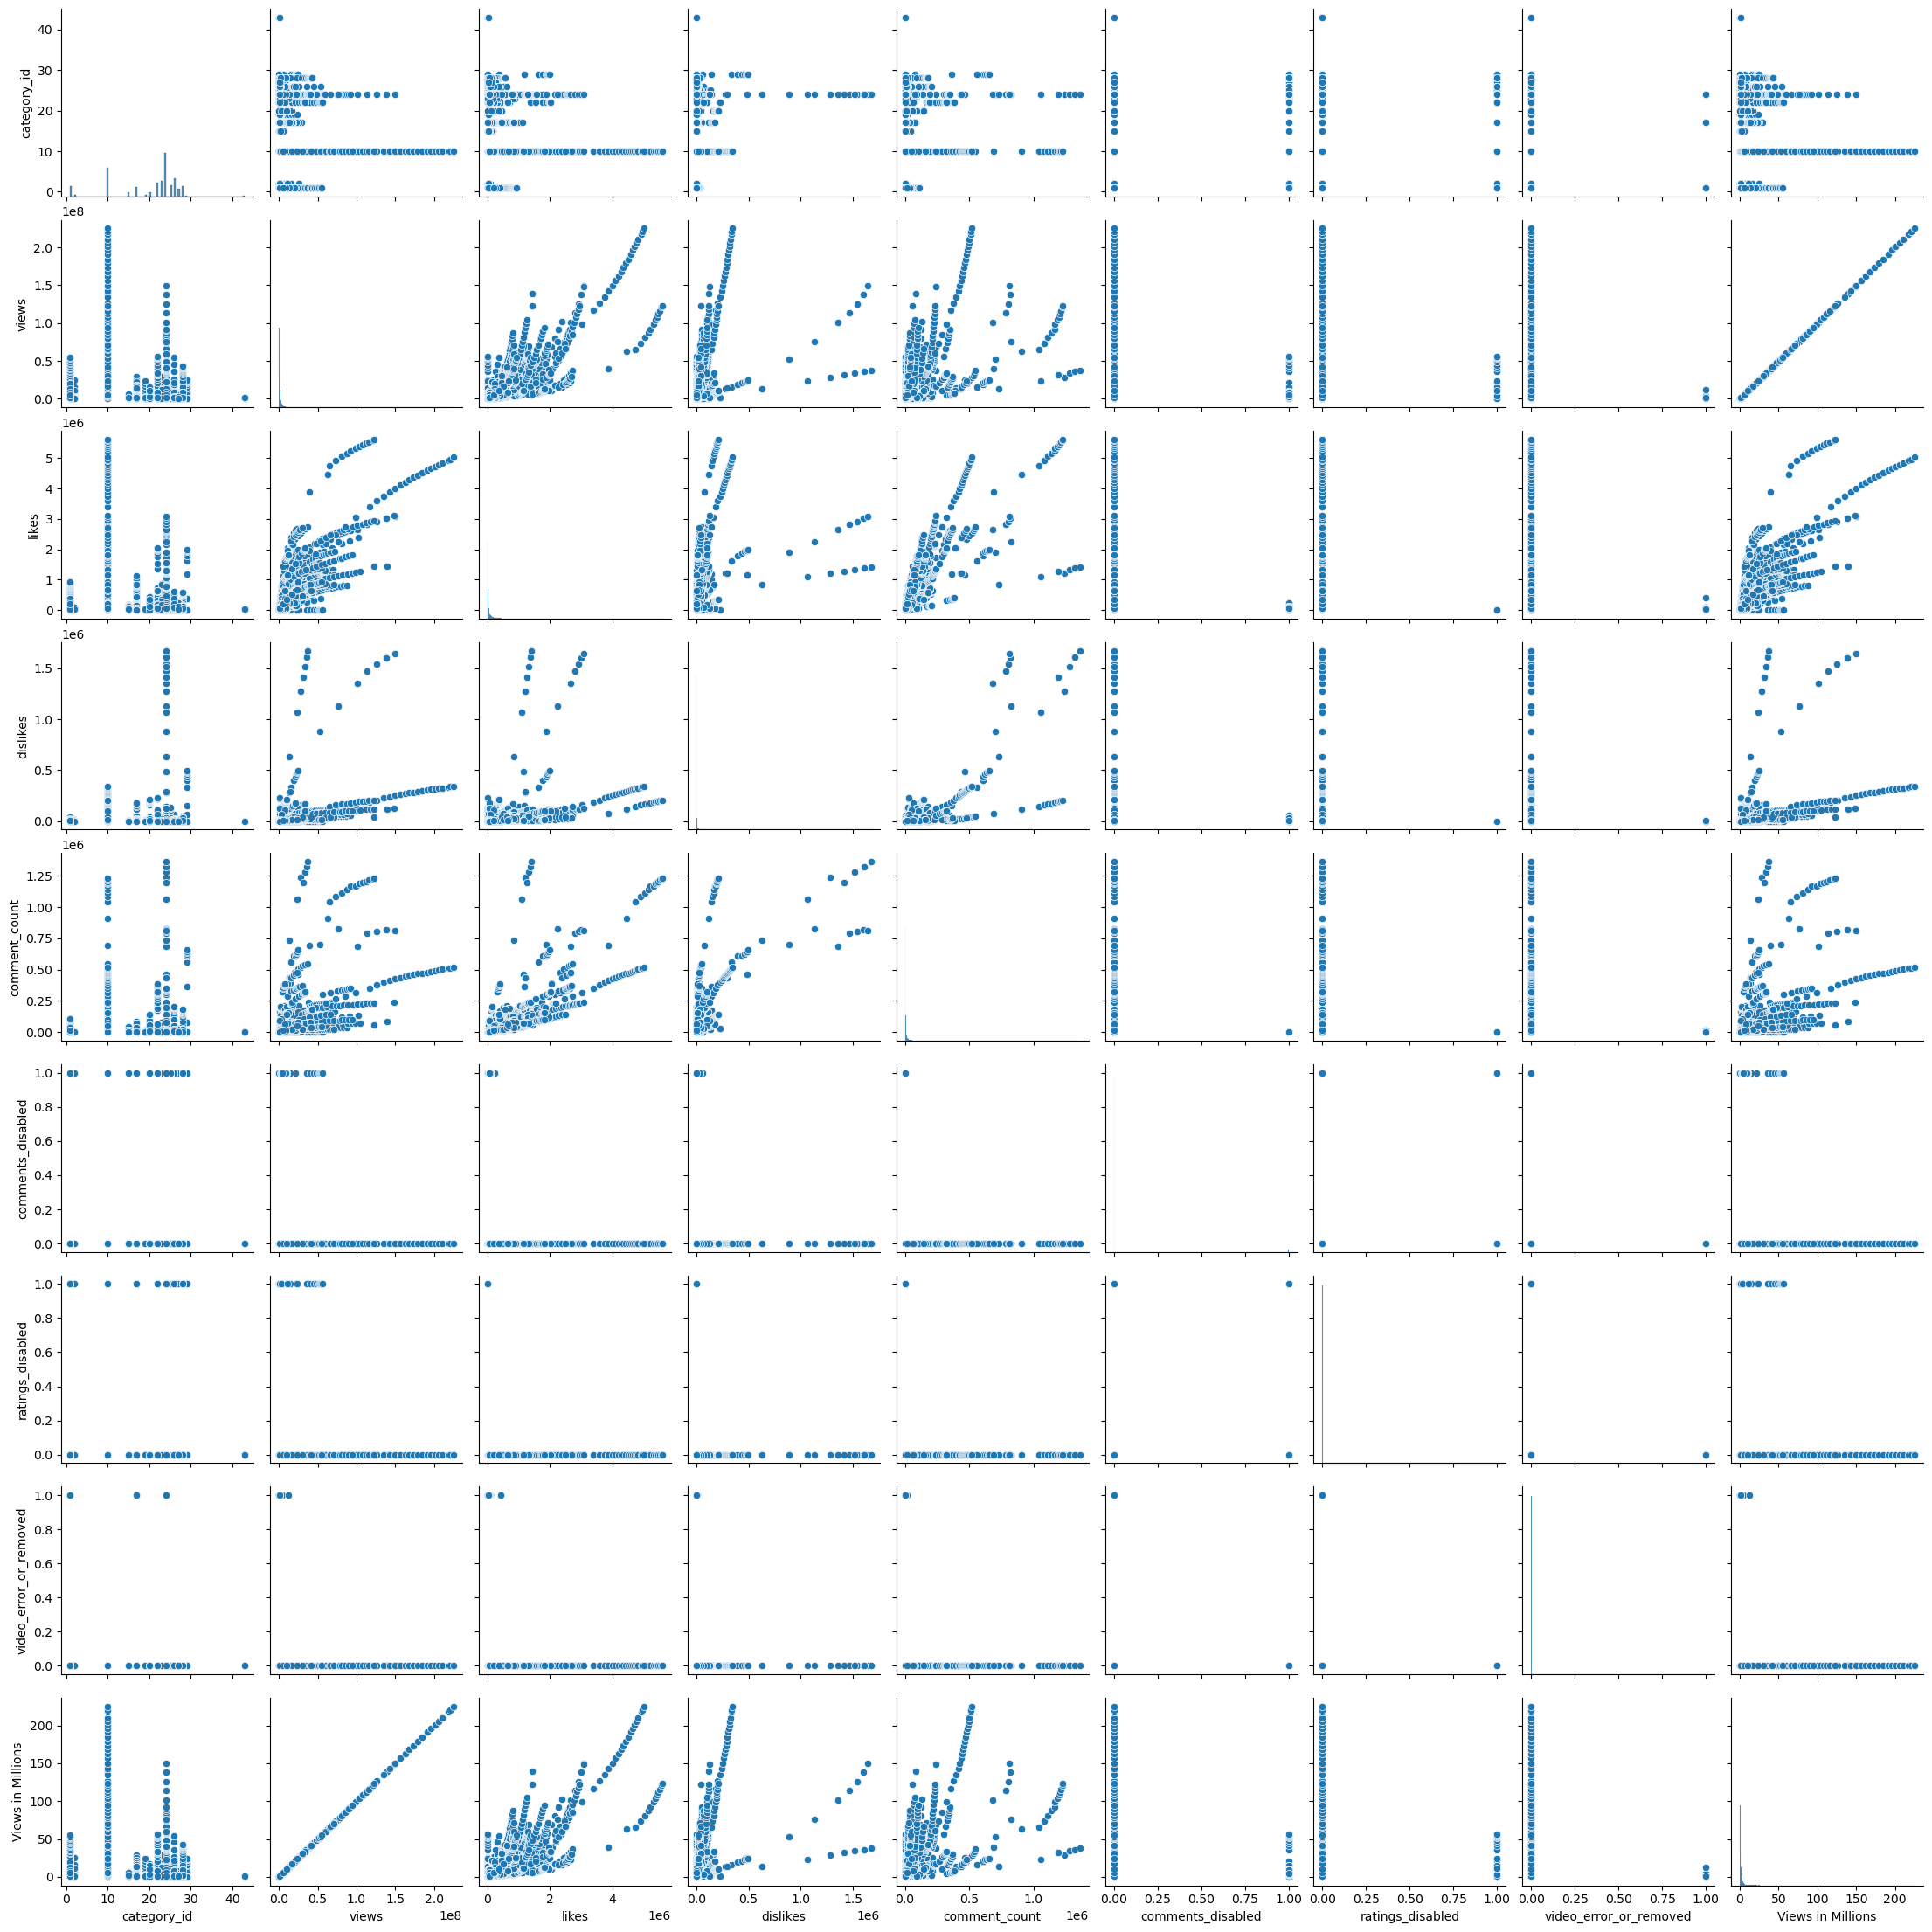

In [142]:
sns.pairplot(yt_df)

In [143]:
yt_df['time uploaded'] = yt_df['publish_time'].dt.time

In [144]:
yt_df.head(

)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,categories,Views in Millions,time uploaded
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:13:01+00:00,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,People & Blogs,0.748374,17:13:01
1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00+00:00,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",Entertainment,2.418783,07:30:00
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12 19:05:24+00:00,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,Comedy,3.191434,19:05:24
3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13 11:00:04+00:00,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,Entertainment,0.343168,11:00:04
4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12 18:01:41+00:00,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,Entertainment,2.095731,18:01:41


In [145]:
yt_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   video_id                40949 non-null  object             
 1   trending_date           40949 non-null  datetime64[ns]     
 2   title                   40949 non-null  object             
 3   channel_title           40949 non-null  object             
 4   category_id             40949 non-null  int64              
 5   publish_time            40949 non-null  datetime64[ns, UTC]
 6   tags                    40949 non-null  object             
 7   views                   40949 non-null  int64              
 8   likes                   40949 non-null  int64              
 9   dislikes                40949 non-null  int64              
 10  comment_count           40949 non-null  int64              
 11  thumbnail_link          40949 non-null  o

TypeError: float() argument must be a string or a real number, not 'datetime.time'

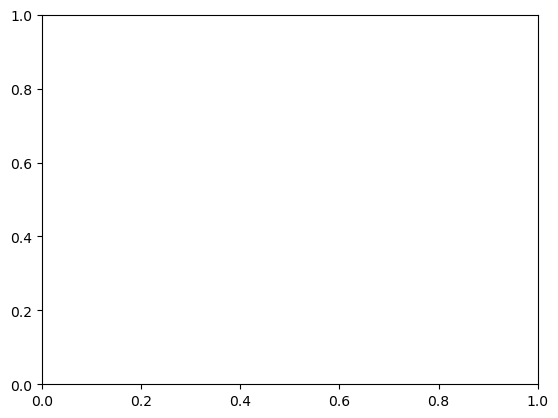

In [149]:
plt.plot(yt_df['time uploaded'], yt_df['views'])